# Assignment 5: Unsupervised Learning for Pattern Discovery and Product Segmentation

**Business Case:** NovaMart Retail Inventory Reorder Decision Support  
**Dataset:** `novamart_inventory_reorder_dataset.xlsx`  
**Machine Learning Method:** K-means Clustering  

This assignment uses unsupervised learning to discover useful product segments in NovaMart's retail inventory dataset. The goal is to identify patterns in product demand, stock levels, pricing, customer interest, and service indicators so that the business can make better marketing and inventory decisions.

## Task 1: Understand the Business Problem

### Main business problem

NovaMart Retail is a mid-sized retail company that sells everyday products through physical stores and an online channel. The company wants to improve inventory and marketing decisions by understanding patterns across product records. The main business problem is that products behave differently: some products have high demand, some have high stock, some are premium-priced, and some may require more marketing or inventory attention.

NovaMart also faces two important inventory risks:

- **Stockouts:** Products run out before the next supplier delivery, which may cause lost sales and lower customer satisfaction.
- **Overstock:** The company orders too much inventory, which increases storage costs and ties up cash.

### Why segmentation is useful

Customer or product segmentation is useful because it divides products into meaningful groups based on similar patterns. Instead of using the same strategy for every product, NovaMart can design different marketing, pricing, and inventory actions for each segment.

### Marketing decisions improved by segmentation

Segmentation can help NovaMart improve decisions such as:

- Which products should receive stronger promotions
- Which products need more inventory monitoring
- Which products may need discounts or bundling
- Which high-value products should receive priority attention
- Which products have strong website interest but may need conversion support
- Which products may require different strategies by season, price level, demand, and customer engagement

## Task 2: Prepare the Dataset

This section loads the dataset, inspects its structure, checks missing values and duplicates, cleans the data, selects numerical features, and scales the features before clustering.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Display all columns clearly
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
# Load the dataset
file_path = "novamart_inventory_reorder_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Dataset")

# Display first five rows
df.head()

,Product_ID,Product_Category,Store_Location,Store_Type,Supplier_Region,Season,Current_Stock_Units,Average_Weekly_Sales,Lead_Time_Days,Unit_Cost,Selling_Price,Discount_Rate,Customer_Rating,Return_Rate,Website_Views,Previous_Stockout,Competitor_Price_Index,Reorder_Needed
0,P0001,Fitness,Downtown,Standard,Local,Back-to-School,31,32,2,10.61,17.87,0.00,3.9,0.08,760,Yes,1.06,No
1,P0002,Kitchenware,Suburban,Flagship,International,Fall,0,25,16,68.41,129.90,0.29,4.1,0.01,532,No,1.15,Yes
2,P0003,Kitchenware,Downtown,Standard,Local,Spring,60,35,5,25.13,48.82,0.16,4.1,0.11,897,No,1.11,No
3,P0004,Fitness,Mall,Standard,International,Back-to-School,111,51,16,27.97,42.97,0.11,4.1,0.10,1108,No,1.19,Yes
4,P0005,Beauty,Suburban,Standard,International,Fall,521,45,23,42.72,59.63,0.00,3.4,0.03,245,No,1.03,Yes


In [3]:
# Check number of rows and columns
df.shape

(365, 18)

In [4]:
# Check column names
df.columns

Index(['Product_ID', 'Product_Category', 'Store_Location', 'Store_Type', 'Supplier_Region', 'Season',
       'Current_Stock_Units', 'Average_Weekly_Sales', 'Lead_Time_Days', 'Unit_Cost', 'Selling_Price', 'Discount_Rate',
       'Customer_Rating', 'Return_Rate', 'Website_Views', 'Previous_Stockout', 'Competitor_Price_Index',
       'Reorder_Needed'],
      dtype='object')

In [5]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Product_ID              365 non-null    object 
 1   Product_Category        365 non-null    object 
 2   Store_Location          365 non-null    object 
 3   Store_Type              365 non-null    object 
 4   Supplier_Region         357 non-null    object 
 5   Season                  365 non-null    object 
 6   Current_Stock_Units     365 non-null    int64  
 7   Average_Weekly_Sales    365 non-null    int64  
 8   Lead_Time_Days          365 non-null    int64  
 9   Unit_Cost               365 non-null    float64
 10  Selling_Price           365 non-null    float64
 11  Discount_Rate           359 non-null    float64
 12  Customer_Rating         355 non-null    float64
 13  Return_Rate             358 non-null    float64
 14  Website_Views           365 non-null    in

In [6]:
# Check missing values
df.isnull().sum()

Product_ID                 0
Product_Category           0
Store_Location             0
Store_Type                 0
Supplier_Region            8
Season                     0
Current_Stock_Units        0
Average_Weekly_Sales       0
Lead_Time_Days             0
Unit_Cost                  0
Selling_Price              0
Discount_Rate              6
Customer_Rating           10
Return_Rate                7
Website_Views              0
Previous_Stockout          0
Competitor_Price_Index     0
Reorder_Needed             0
dtype: int64

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(5)

In [8]:
# Remove duplicate rows
df_clean = df.drop_duplicates().copy()

# Confirm new shape after removing duplicates
df_clean.shape

(360, 18)

In [9]:
# Select numerical features useful for clustering
# Product_ID is an identifier and Reorder_Needed is a target-like label, so they are not used for clustering.

numerical_features = [
    'Current_Stock_Units',
    'Average_Weekly_Sales',
    'Lead_Time_Days',
    'Unit_Cost',
    'Selling_Price',
    'Discount_Rate',
    'Customer_Rating',
    'Return_Rate',
    'Website_Views',
    'Competitor_Price_Index']

X = df_clean[numerical_features].copy()
X.head()

,Current_Stock_Units,Average_Weekly_Sales,Lead_Time_Days,Unit_Cost,Selling_Price,Discount_Rate,Customer_Rating,Return_Rate,Website_Views,Competitor_Price_Index
0,31,32,2,10.61,17.87,0.00,3.9,0.08,760,1.06
1,0,25,16,68.41,129.90,0.29,4.1,0.01,532,1.15
2,60,35,5,25.13,48.82,0.16,4.1,0.11,897,1.11
3,111,51,16,27.97,42.97,0.11,4.1,0.10,1108,1.19
4,521,45,23,42.72,59.63,0.00,3.4,0.03,245,1.03


In [10]:
# Handle missing numerical values using median imputation
# Median is appropriate because it is less affected by outliers than the mean.

X = X.fillna(X.median())

# Confirm missing values are handled
X.isnull().sum()

Current_Stock_Units       0
Average_Weekly_Sales      0
Lead_Time_Days            0
Unit_Cost                 0
Selling_Price             0
Discount_Rate             0
Customer_Rating           0
Return_Rate               0
Website_Views             0
Competitor_Price_Index    0
dtype: int64

In [11]:
# Scale the selected numerical features before applying K-means
# Scaling is required because K-means is distance-based.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-7.77052060e-01, -8.71314208e-01, -1.24870588e+00,
        -1.51823814e+00, -1.48062645e+00, -1.16326439e+00,
        -2.32829415e-01, -2.61730531e-01, -7.89037564e-01,
         3.14333492e-01],
       [-1.17987169e+00, -1.29907805e+00,  1.70875542e+00,
         1.21222852e+00,  1.29333127e+00,  1.33817335e+00,
         2.15398336e-01, -1.93574307e+00, -1.20249911e+00,
         1.12197863e+00],
       [-4.00220793e-01, -6.87986847e-01, -6.14964175e-01,
        -8.32314684e-01, -7.14278225e-01,  2.16839192e-01,
         2.15398336e-01,  4.55703412e-01, -5.40597950e-01,
         7.63025234e-01],
       [ 2.62482468e-01,  2.89759079e-01,  1.70875542e+00,
        -6.98153346e-01, -8.59129181e-01, -2.14443179e-01,
         2.15398336e-01,  2.16558764e-01, -1.57964676e-01,
         1.48093202e+00],
       [ 5.59009692e+00, -7.68956431e-02,  3.18748607e+00,
        -1.36470844e-03, -4.46613466e-01, -1.16326439e+00,
        -1.35339879e+00, -1.45745377e+00, -1.72295290e+00,
         4.

## Task 3: Apply K-means Clustering

The Elbow Method is used to compare different values of k. The final number of clusters is selected by looking for the point where inertia begins to decrease more slowly.

In [12]:
# Use the Elbow Method to help select a suitable number of clusters

inertias = []
k_values = range(1, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Display inertia values
elbow_results = pd.DataFrame({
    'Number_of_Clusters': list(k_values),
    'Inertia': inertias})

elbow_results

,Number_of_Clusters,Inertia
0,1,3600.000000
1,2,3067.444413
2,3,2719.616402
3,4,2515.242892
4,5,2363.442201
5,6,2266.698481
6,7,2151.152678
7,8,2073.202385


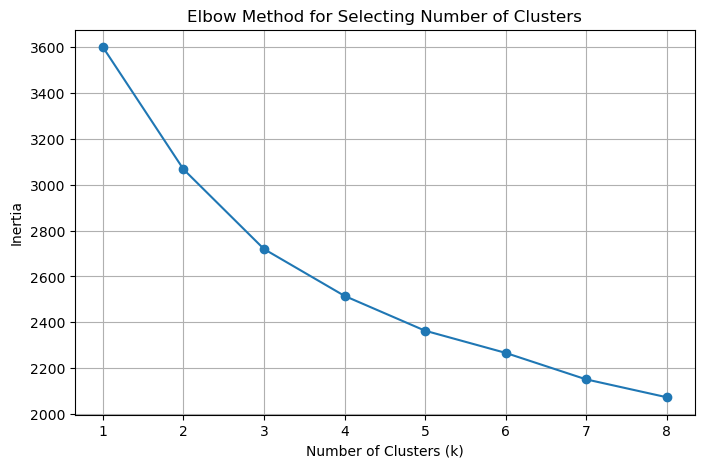

In [13]:
# Plot the Elbow Method chart

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method for Selecting Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [14]:
# Supporting check: silhouette scores for k = 2 to 8
# Higher silhouette scores usually indicate better-defined clusters.

silhouette_results = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append([k, score])

silhouette_df = pd.DataFrame(silhouette_results, columns=['Number_of_Clusters', 'Silhouette_Score'])
silhouette_df

,Number_of_Clusters,Silhouette_Score
0,2,0.140894
1,3,0.135547
2,4,0.127700
3,5,0.124431
4,6,0.109608
5,7,0.119226
6,8,0.114048


### Number of clusters selected

Based on the Elbow Method, **3 clusters** were selected. The inertia decreases as k increases, but after around k = 3, the improvement becomes more gradual. Three clusters also provide a practical business interpretation because the products can be grouped into clear product segments that managers can understand and act on.

Although the silhouette scores are not very high, this is common in real business-style datasets where product behaviours overlap. K-means still provides a useful starting point for pattern discovery and business segmentation.

In [15]:
# Train the final K-means model with 3 clusters

final_k = 3
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels back to the cleaned dataset
df_clean['Cluster'] = cluster_labels

# Display first rows with cluster labels
df_clean.head()

,Product_ID,Product_Category,Store_Location,Store_Type,Supplier_Region,Season,Current_Stock_Units,Average_Weekly_Sales,Lead_Time_Days,Unit_Cost,Selling_Price,Discount_Rate,Customer_Rating,Return_Rate,Website_Views,Previous_Stockout,Competitor_Price_Index,Reorder_Needed,Cluster
0,P0001,Fitness,Downtown,Standard,Local,Back-to-School,31,32,2,10.61,17.87,0.00,3.9,0.08,760,Yes,1.06,No,1
1,P0002,Kitchenware,Suburban,Flagship,International,Fall,0,25,16,68.41,129.90,0.29,4.1,0.01,532,No,1.15,Yes,2
2,P0003,Kitchenware,Downtown,Standard,Local,Spring,60,35,5,25.13,48.82,0.16,4.1,0.11,897,No,1.11,No,1
3,P0004,Fitness,Mall,Standard,International,Back-to-School,111,51,16,27.97,42.97,0.11,4.1,0.10,1108,No,1.19,Yes,1
4,P0005,Beauty,Suburban,Standard,International,Fall,521,45,23,42.72,59.63,0.00,3.4,0.03,245,No,1.03,Yes,0


In [16]:
# Check the number of products in each cluster
df_clean['Cluster'].value_counts().sort_index()

Cluster
0    102
1    124
2    134
Name: count, dtype: int64

## Task 4: Analyze and Interpret the Clusters

This section analyzes the average characteristics of each product segment.

In [17]:
# Calculate average numerical characteristics by cluster

cluster_summary = df_clean.groupby('Cluster')[numerical_features].mean().round(2)
cluster_summary

,Current_Stock_Units,Average_Weekly_Sales,Lead_Time_Days,Unit_Cost,Selling_Price,Discount_Rate,Customer_Rating,Return_Rate,Website_Views,Competitor_Price_Index
Cluster,,,,,,,,,,
0,156.63,62.91,9.68,43.48,80.38,0.11,3.94,0.11,1737.15,1.03
1,67.59,41.95,6.89,22.05,39.26,0.12,3.97,0.08,1039.90,1.01
2,62.17,37.57,7.51,61.35,111.15,0.16,4.09,0.09,926.14,1.03


In [18]:
# Add product count and reorder-needed rate to the summary

cluster_counts = df_clean['Cluster'].value_counts().sort_index()
reorder_rate = (df_clean.groupby('Cluster')['Reorder_Needed']
                .apply(lambda x: (x == 'Yes').mean()) * 100).round(1)

cluster_business_summary = cluster_summary.copy()
cluster_business_summary.insert(0, 'Number_of_Products', cluster_counts)
cluster_business_summary['Reorder_Needed_Rate_%'] = reorder_rate

cluster_business_summary

,Number_of_Products,Current_Stock_Units,Average_Weekly_Sales,Lead_Time_Days,Unit_Cost,Selling_Price,Discount_Rate,Customer_Rating,Return_Rate,Website_Views,Competitor_Price_Index,Reorder_Needed_Rate_%
Cluster,,,,,,,,,,,,
0,102,156.63,62.91,9.68,43.48,80.38,0.11,3.94,0.11,1737.15,1.03,27.5
1,124,67.59,41.95,6.89,22.05,39.26,0.12,3.97,0.08,1039.90,1.01,26.6
2,134,62.17,37.57,7.51,61.35,111.15,0.16,4.09,0.09,926.14,1.03,38.1


In [20]:
# Give each cluster a business-friendly name

cluster_names = {
    0: 'High Demand / High Stock Products',
    1: 'Low-Cost Moderate Demand Products',
    2: 'Premium Low-Stock Products'}

df_clean['Segment_Name'] = df_clean['Cluster'].map(cluster_names)

df_clean[['Product_ID', 'Product_Category', 'Current_Stock_Units', 'Average_Weekly_Sales',
          'Selling_Price', 'Website_Views', 'Cluster', 'Segment_Name']].head(10)

,Product_ID,Product_Category,Current_Stock_Units,Average_Weekly_Sales,Selling_Price,Website_Views,Cluster,Segment_Name
0,P0001,Fitness,31,32,17.87,760,1,Low-Cost Moderate Demand Products
1,P0002,Kitchenware,0,25,129.90,532,2,Premium Low-Stock Products
2,P0003,Kitchenware,60,35,48.82,897,1,Low-Cost Moderate Demand Products
3,P0004,Fitness,111,51,42.97,1108,1,Low-Cost Moderate Demand Products
4,P0005,Beauty,521,45,59.63,245,0,High Demand / High Stock Products
5,P0006,Kitchenware,98,38,63.63,1567,1,Low-Cost Moderate Demand Products
6,P0007,Apparel,155,75,38.56,2569,0,High Demand / High Stock Products
7,P0008,Apparel,81,85,93.74,2266,0,High Demand / High Stock Products
8,P0009,Home Goods,44,54,14.19,1503,1,Low-Cost Moderate Demand Products
9,P0010,Beauty,29,88,69.09,2040,0,High Demand / High Stock Products


### Cluster Interpretation

The K-means model identified **3 product segments**. These segments are not labels that existed in the original dataset. They were discovered by the model based on numerical patterns such as stock level, weekly sales, lead time, cost, selling price, discount rate, customer rating, return rate, website views, and competitor price index.

### Cluster 0: High Demand / High Stock Products

This segment contains **102 products**. It has the highest average current stock, highest average weekly sales, highest website views, and the longest supplier lead time.

**Technical result:** Cluster 0 has stronger sales activity and stronger online interest compared with the other clusters.

**Business meaning:** These products are likely important revenue drivers for NovaMart. Even though they currently have high stock, their high demand means stockouts could still happen if managers do not monitor them carefully. The longer supplier lead time also means that late reordering could create availability problems.

**Business action:** NovaMart should prioritize inventory planning for this segment, monitor supplier lead times, and maintain availability. These products can also be featured in marketing campaigns because they already show strong customer interest.

### Cluster 1: Low-Cost Moderate Demand Products

This segment contains **124 products**. It has lower unit cost, lower selling price, moderate weekly sales, and moderate website views.

**Technical result:** Cluster 1 represents affordable products with steady but not extremely high demand.

**Business meaning:** These products may support regular customer purchases and basket size. They may not be the highest-value products individually, but they can contribute to frequent sales and customer convenience.

**Business action:** NovaMart should use bundle offers, small discounts, cross-selling, and everyday-value promotions for this segment. The goal should be to increase sales volume without spending too much on marketing.

### Cluster 2: Premium Low-Stock Products

This segment contains **134 products**. It has the highest average unit cost and selling price, but lower stock levels, lower average weekly sales, and lower website views. It also has the highest reorder-needed rate among the clusters.

**Technical result:** Cluster 2 represents higher-priced products with lower demand and lower inventory levels.

**Business meaning:** These products may have higher profit potential per item, but they also create inventory risk. Overstocking them can tie up cash, while understocking them may cause missed sales for premium products.

**Business action:** NovaMart should use targeted marketing instead of broad discounts. The business should protect profit margins, monitor reorder needs closely, and promote these products to customers who are more likely to buy premium items.

### Most valuable segment

**Cluster 0: High Demand / High Stock Products** may be the most valuable segment because it has the highest average weekly sales and highest website views. These products attract strong customer interest and contribute actively to sales.

### Segment needing more marketing attention

**Cluster 2: Premium Low-Stock Products** may need more marketing attention because it contains higher-priced products with lower demand and lower website views. Since these products are expensive, NovaMart should avoid broad discounting and instead use targeted promotions, product recommendations, and margin-protecting campaigns.

## Task 5: Visualize the Clusters

This section creates visualizations to support the clustering analysis and business interpretation.

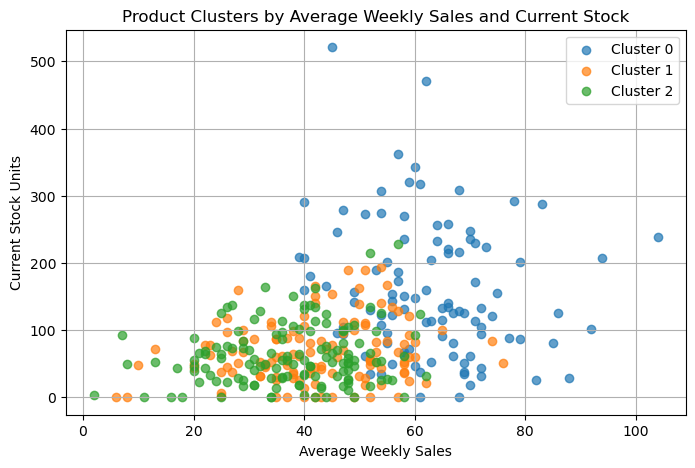

In [21]:
# Visualization 1: Scatter plot using Average Weekly Sales and Current Stock Units

plt.figure(figsize=(8, 5))

for cluster in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == cluster]
    plt.scatter(subset['Average_Weekly_Sales'], subset['Current_Stock_Units'],
                label=f'Cluster {cluster}', alpha=0.7)

plt.title('Product Clusters by Average Weekly Sales and Current Stock')
plt.xlabel('Average Weekly Sales')
plt.ylabel('Current Stock Units')
plt.legend()
plt.grid(True)
plt.show()

### Scatter Plot Interpretation

The scatter plot compares products based on **Average Weekly Sales** and **Current Stock Units**. Cluster 0 appears higher in both sales and stock compared with the other clusters.

**Business meaning:** This shows that Cluster 0 products are active products with strong inventory movement. These products should not be ignored just because they currently have high stock. Since they sell more frequently, they may still face stockout risk if demand continues.

**Business action:** NovaMart should monitor Cluster 0 closely, especially before busy sales periods. For Clusters 1 and 2, the business should use different strategies because these products do not show the same combination of high sales and high stock.

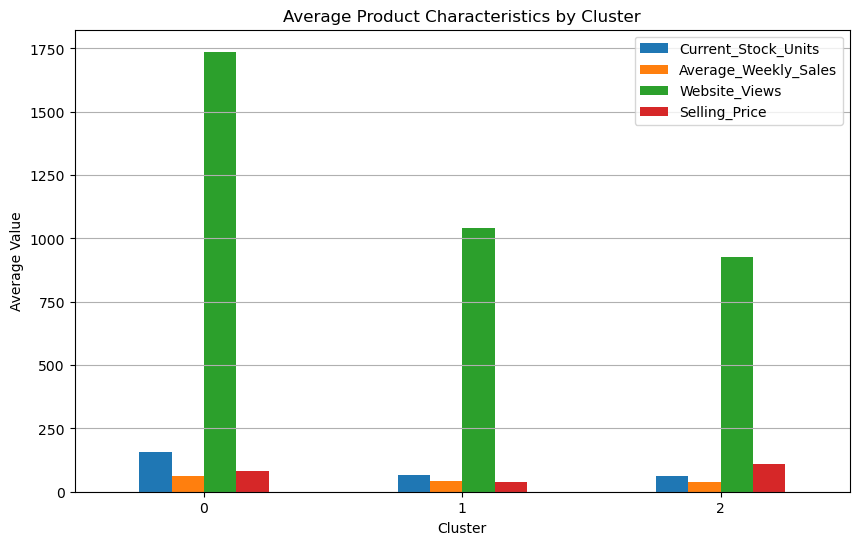

In [22]:
# Visualization 2: Bar chart comparing average selected features across clusters

cluster_avg_for_plot = df_clean.groupby('Cluster')[
    ['Current_Stock_Units', 'Average_Weekly_Sales', 'Website_Views', 'Selling_Price']
].mean()

cluster_avg_for_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Average Product Characteristics by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Bar Chart Interpretation

The bar chart compares average stock, sales, website views, and selling price across the three clusters.

**Technical result:** Cluster 0 has higher website views, stock, and sales activity. Cluster 2 has the highest selling price. Cluster 1 has lower prices and moderate demand.

**Business meaning:** The chart confirms that each cluster needs a different business strategy. Cluster 0 is demand-driven, Cluster 1 is value-driven, and Cluster 2 is premium-price-driven.

**Business action:** NovaMart should protect inventory availability for Cluster 0, use promotional bundles for Cluster 1, and use targeted premium marketing for Cluster 2.

<Figure size 800x500 with 0 Axes>

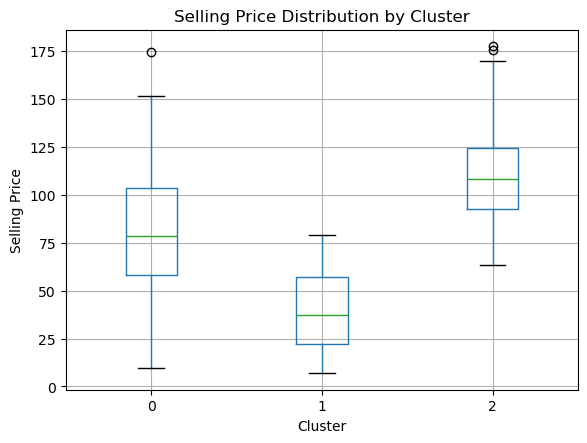

In [23]:
# Visualization 3: Box plot comparing selling price by cluster

plt.figure(figsize=(8, 5))
df_clean.boxplot(column='Selling_Price', by='Cluster')
plt.title('Selling Price Distribution by Cluster')
plt.suptitle('')
plt.xlabel('Cluster')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

### Box Plot Interpretation

The box plot compares the distribution of selling prices across clusters.

**Technical result:** Cluster 2 has the highest selling price range, which supports the interpretation that it contains premium products.

**Business meaning:** Premium products require more careful decisions because each unit ties up more cash. Heavy discounting may reduce profit margins, while overstocking may increase holding costs.

**Business action:** NovaMart should use careful demand monitoring and targeted marketing for Cluster 2 rather than treating it like a low-cost promotion segment.

## Task 6: Business Interpretation and Recommendations

### Patterns discovered

The clustering analysis discovered three main product segments:

1. **High Demand / High Stock Products**
2. **Low-Cost Moderate Demand Products**
3. **Premium Low-Stock Products**

The segments differ mainly in stock level, sales activity, selling price, website interest, and reorder risk. This shows that NovaMart should not use the same marketing and inventory strategy for every product.

### How NovaMart can use these segments

NovaMart can use these clusters to make better marketing and inventory decisions. The clusters help managers understand which products are high-demand, which products are affordable and steady, and which products are premium but need more careful attention.

### Suggested marketing strategy for each segment

**Cluster 0: High Demand / High Stock Products**  
NovaMart should maintain strong inventory availability for these products because they have high weekly sales and high website views. These products can be promoted in campaigns because customer interest is already strong. The business should also watch supplier lead times carefully so that popular products do not run out.

**Cluster 1: Low-Cost Moderate Demand Products**  
NovaMart should use bundles, small discounts, cross-selling, and everyday-value promotions. These products can help increase basket size and encourage repeat purchases. Since they are lower-cost products, marketing actions should focus on volume and convenience.

**Cluster 2: Premium Low-Stock Products**  
NovaMart should use targeted marketing, personalized recommendations, and careful reorder planning. Since these products have higher selling prices, broad discounts may hurt profit margins. The business should focus on reaching customers who are likely to value premium products.

### How this improves decision-making

This analysis helps NovaMart allocate resources more effectively. Instead of spending the same marketing budget on all products, the company can focus different actions on different segments. This can improve inventory planning, reduce stockout risk, avoid unnecessary overstock, protect profit margins, and make marketing campaigns more relevant.

## Task 7: Limitations and Responsible AI Reflection

### One limitation of the dataset or clustering model

One limitation is that the dataset is synthetic and simplified for teaching purposes. It may not include all real-world factors such as supplier disruptions, advertising campaigns, local events, changing customer preferences, competitor promotions, weather, or sudden demand changes.

Another limitation is that some product behaviours may overlap. A product may not perfectly belong to only one segment, but K-means still forces every product into one cluster.

### Why K-means does not always produce perfect segments

K-means does not always produce perfect customer or product segments because it groups records based on distance from cluster centers. It assumes that clusters are roughly circular and similar in size. Real business data may be more complex, with overlapping groups, outliers, seasonal patterns, and changing customer behaviour.

### Possible bias or unfair decision

If NovaMart uses these clusters without human review, it may over-prioritize products that already have high website views or past sales. At the same time, new products with limited history may receive less inventory or marketing support. This could create a bias where established products keep receiving more attention while new products struggle to gain visibility.

### Why human judgment is still needed

Human judgment is still needed because clustering results are decision-support tools, not final decisions. Managers understand business context that may not appear in the dataset, such as planned promotions, supplier delays, local events, seasonal demand, or strategic product launches. Human review helps ensure that marketing and inventory actions are fair, practical, and aligned with NovaMart's business goals.

In [24]:
# Save final dataset with cluster labels for GitHub submission

df_clean.to_csv('novamart_clustered_dataset.csv', index=False)
print('Clustered dataset saved as novamart_clustered_dataset.csv')

Clustered dataset saved as novamart_clustered_dataset.csv


# Final Conclusion

This assignment used K-means clustering to identify meaningful product segments within NovaMart's inventory dataset. The analysis discovered three distinct segments with different demand patterns, stock levels, pricing characteristics, website interest levels, and reorder risk.

The results show that not all products should be managed using the same strategy. High-demand products require strong inventory planning and stock availability. Low-cost moderate-demand products can benefit from bundles, discounts, and cross-selling. Premium low-stock products require targeted marketing and careful margin protection.

These findings help NovaMart make more informed inventory and marketing decisions. By using data-driven product segmentation, the company can allocate resources more effectively, improve customer satisfaction, reduce stockout risk, avoid unnecessary overstock, and support long-term profitability.

However, clustering results should be used alongside human judgment because K-means is a simplified model and may not capture all real-world business conditions, seasonal effects, new product potential, or strategic considerations.